## Adrianna Kostrzewa 251170 14.12.2025

# Analiza Danych - projekt końcowy


# Choroba serca

<div style="text-align: center;">
<img src="./zdj.jpg" alt="Choroba serca" width="25%">
</div>

### 1. Opis problemu
Jest to zbór medyczny zawierający dane pacjentów z Cleveland Clinic Foundation. Służy do trenowania modeli, które mają przewidywać, czy pacjent cierpi na chorobe serca.
* Liczba pacjentów (wierszy): 303
* Liczba cech (kolumn): 14 (w tym diagnoza)
* Rodzaj problemu: Klasyfikacja (chory / zdrowy)

Opis kolumn:
* wiek (wiek pacjenta w latach)
* plec (mężczyzna-1 /kobieta-0)
* cp (rodzaj bólu w klatce)
    1. angina (ból wywołany wysiłkiem)
    2. atypical angina (ból nietypowy)
    3. non-anginal (ból niedławicowy)
    4. asymptomatic (brak objawów)
* trestbps (ciśnienie spoczynkowe mierzone w mm Hg)
* chol (poziom cholesterolu w mg/dl)
* fbs (cukier we krwi na czczo, > 120mg/dl, 1 = true, 0 = false)
* restecg (EKG spoczynkowe)
* thalach (maksymalne tętno)
* exang (dławica wysiłakowa, czy wystąpił ból (tak/nie))
* oldpeak (obniżenie odcinka ST (niedokrwienie serca))
* slope (nachylenie odcinka ST)
* ca (liczba naczyń głównych)
* thal (badanie przepływu krwi)
* target (diagnoza)

Nazwa zbioru danych: Heart Disease

Źródło danych: UCI Machine Learning Repository 

In [1]:
# Potrzebne biblioteki
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder

# Automatycznie dzieli zbiór
from sklearn.model_selection import train_test_split


# Dzielenie zbioru danych
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ocena jakości modeli
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Dla modelu klasyfikacji
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

from sklearn.metrics import roc_curve, auc

In [2]:
# Wczytanie danych
dane = 'processed.cleveland.data'

In [3]:
# Zdefiniowanie nazwy kolumn, ze wzgledu na brak w oryginalnym pliku
kolumny = ['wiek', 'plec', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Odczytanie danych w formacie csv podkreślając, że nie ma nagłówka
df = pd.read_csv(dane, header=None, names=kolumny, na_values='?')

## 2. Opis danych

In [4]:
# Wyświetlenie 5 pierwszych rekordów
df.head()

,wiek,plec,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Wyświetlanie typu danych
df.dtypes

wiek        float64
plec        float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

In [6]:
# Wyświetlanie listy kolumn
df.columns

Index(['wiek', 'plec', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
# Wyświetlanie informacji o obiekcie DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wiek      303 non-null    float64
 1   plec      303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [8]:
# Wyświetli sumę danych dal każdej kolumn
print(df.isnull().sum())

wiek        0
plec        0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [9]:
# Wyświetlanie statystuki opisowej
df.describe().round(2)

,wiek,plec,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


Ze statystyk wynika, że najbardziej dotknięci są pacjenci w wieku średnim (29 lat) i podeszłym (79 lat). Mężczyźni dominują - 68%, a kobiety - 32%. Wysoki poziom cholesterolu wiążę się z większym ryzykiem chorób serca.

## 3. Przygotowanie danych
### a) Czyszczenie danych
#### Imputacja danych

In [10]:
# Wyświetlenie wszystkich wierszy gdzie są braki
braki = df[df.isnull().any(axis=1)]
display(braki)

,wiek,plec,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [11]:
num_cols = df.select_dtypes(include="number").columns
im = KNNImputer()
imputedKNN = im.fit_transform(df[num_cols])

In [12]:
# Tworzenie znów ramki danych
df = pd.DataFrame(imputedKNN,columns=num_cols)

In [13]:
# zapiujem liste z brakami
wiersze_z_brakami = [87, 166, 192, 266, 287, 302]

In [14]:
# Sprawdzenie czy wiersze z brakami są uzupełnione
display(df.iloc[wiersze_z_brakami])

,wiek,plec,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,5.4,0.0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,0.6,3.0,0.0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,0.6,7.0,1.0
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,3.8,2.0
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,1.6,7.0,0.0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,3.0,0.0


#### Elementy odstające

In [15]:
# Wybieram tylko kolumny, gdzie mogą wystąpić wartości odstające
kolumny_odst = ['wiek', 'trestbps', 'chol', 'thalach', 'oldpeak']

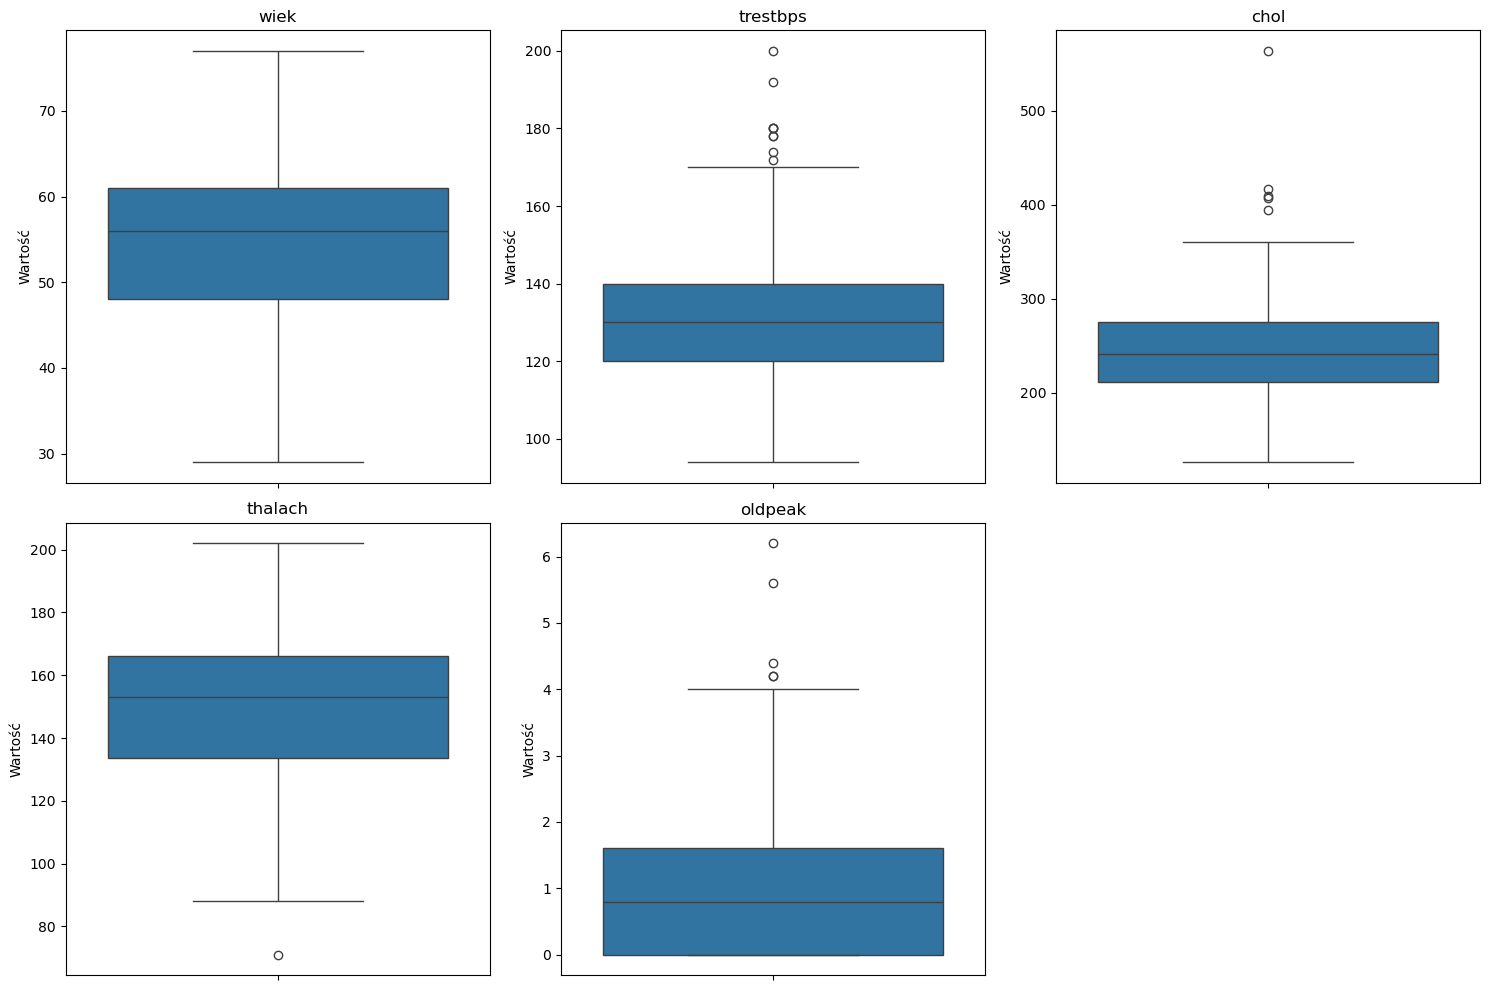

In [16]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(kolumny_odst, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel('Wartość')

plt.tight_layout()
plt.show()

Nie usuwam żadnych danych odstających, ponieważ nie występuje w nich niemożliwa wartość, którą pacjent ma wpisaną. Te mocno odstające wartości świadczą jedynie o bardzo zaawansowanej chorobie pacjenta. 

#### Duplikacje

In [17]:
liczba_duplikatow = df.duplicated().sum()
print(f"Liczba znalezionych duplikatów: {liczba_duplikatow}")

Liczba znalezionych duplikatów: 0


Nie występują duplikacje w takim razie nie popsują uczenia maszynowego.

### b) Wybór cech

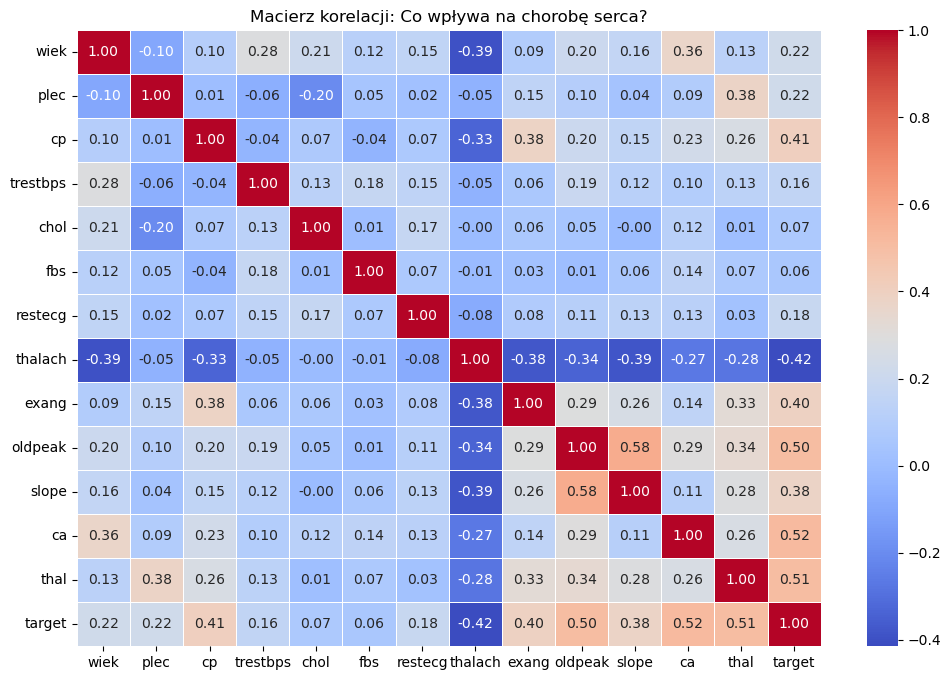

Siła związku z chorobą (od 1.0 do -1.0):
target      1.000000
ca          0.515579
thal        0.506249
oldpeak     0.504092
cp          0.407075
exang       0.397057
slope       0.377957
plec        0.224469
wiek        0.222853
restecg     0.183696
trestbps    0.157754
chol        0.070909
fbs         0.059186
thalach    -0.415040
Name: target, dtype: float64


In [18]:
# --- ANALIZA KORELACJI ---

# 1. Obliczamy macierz korelacji dla całego zbioru
korelacja = df.corr()

# 2. Rysujemy mapę ciepła (Heatmap) - to ułatwia wzrokową ocenę
plt.figure(figsize=(12, 8))
sns.heatmap(korelacja, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Macierz korelacji: Co wpływa na chorobę serca?")
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# 3. Wypisujemy dokładne wartości korelacji tylko dla kolumny 'target'
# Sortujemy od największej do najmniejszej, żeby widzieć liderów
wplyw_na_chorobe = korelacja['target'].sort_values(ascending=False)

print("Siła związku z chorobą (od 1.0 do -1.0):")
print(wplyw_na_chorobe)

In [19]:
# Wybieram tylko cechy numeryczne 
num_df = df.select_dtypes(include="number")

# Obliczam macierz korelacji
corr_matrix = num_df.corr().abs()  # abs(), żeby uwzględnić też silne korelacje ujemne

# Wybieram jedynie górny trójkąt macierzy
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Wybieram cechy silnie skorelowane
threshold = 0.9  # próg korelacji
to_drop = [
    column
    for column in upper_tri.columns 
    if any(upper_tri[column] > threshold)
]

print("Liczba cech do usunięcia:", len(to_drop))
print("Cechy do usunięcia (wysoka korelacja):", to_drop)


Liczba cech do usunięcia: 0
Cechy do usunięcia (wysoka korelacja): []


W tym przypadku wszystkie dane są wystarczająco ważne aby brac je pod uwagę i nie powodują znacznych szumów.

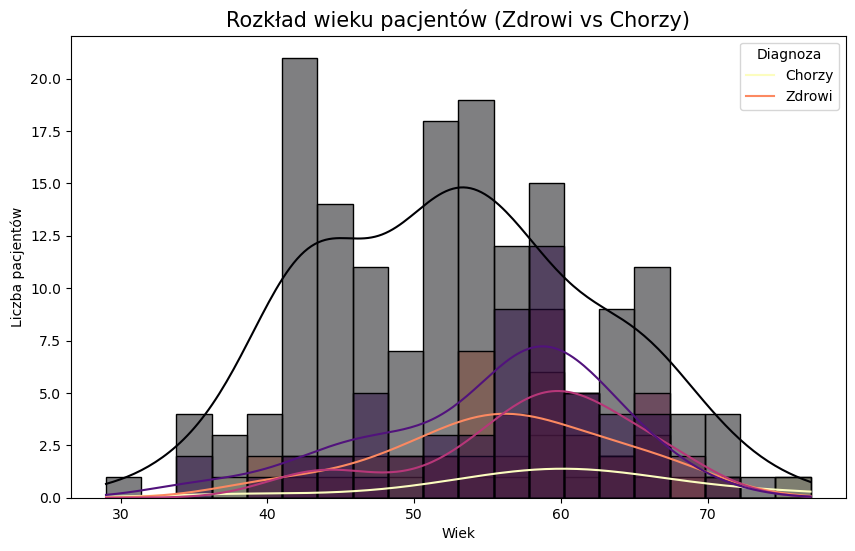

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='wiek', hue='target', kde=True, palette='magma', bins=20)

plt.title("Rozkład wieku pacjentów (Zdrowi vs Chorzy)", fontsize=15)
plt.xlabel("Wiek")
plt.ylabel("Liczba pacjentów")
plt.legend(title='Diagnoza', labels=['Chorzy', 'Zdrowi'])
plt.show()

Największy odsetek chorych występuej w okolicach 60 lat.

#### Przeanalizujmy jeszcze wykres zależności wielu, a tetno maksymaln pacjenta.

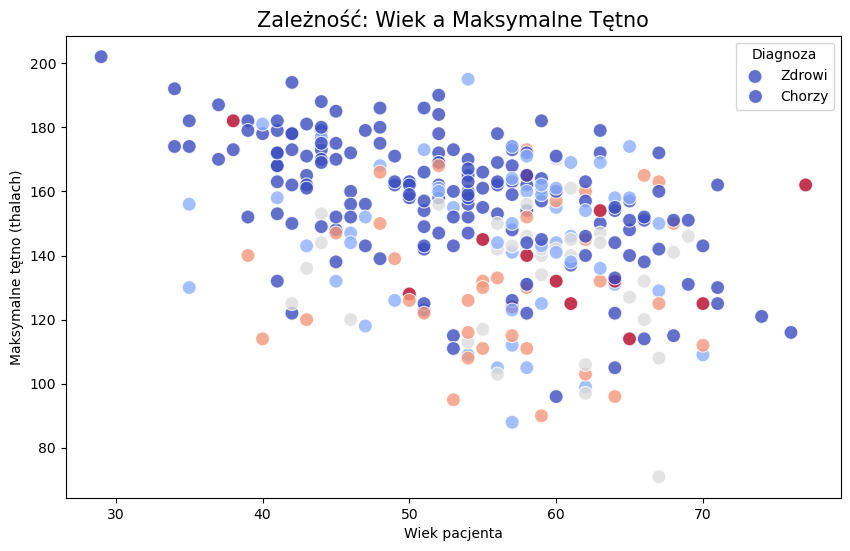

In [21]:
# --- WYKRES 4: Wiek vs Tętno (Thalach) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='wiek', y='thalach', hue='target', data=df, palette='coolwarm', s=100, alpha=0.8)

plt.title("Zależność: Wiek a Maksymalne Tętno", fontsize=15)
plt.xlabel("Wiek pacjenta")
plt.ylabel("Maksymalne tętno (thalach)")
plt.legend(title='Diagnoza', labels=['Zdrowi', 'Chorzy'])
plt.show()

Chozi pacjenci (kolor pomarańczowy) częściej mają niższe tętno maksymalne.

### c) Przekztałcanie danych

* Potrzebuje zmienić kolumne **target (kolumna wynikowa)** na klasyfikacje binarną (chory-1/zdrowy-0) 

In [22]:
# Przekształcenie kolumny na binarną
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [23]:
# Wyświetlenie targetu po przekształceniu
df['target']

0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: target, Length: 303, dtype: int64

#### Ręczna binaryzacja

In [24]:
# 1. CP (Ból w klatce)
# Wg dokumentacji: 1, 2, 3 to różne rodzaje bólu/dławicy, 4 to "bezobjawowy" (asymptomatic).
# Zamieniam na: 1 = boli (wartości 1,2,3), 0 = nie boli (wartość 4)
df['cp_norma'] = df['cp'].apply(lambda x: 0 if x == 4 else 1)

# 2. RESTECG (EKG spoczynkowe)
# 0 = norma. 1 i 2 = anomalie (np. przerost komory)
# Zamieniam na: 0 = norma, 1 = brak normy
df['restecg_norma'] = df['restecg'].apply(lambda x: 0 if x == 0 else 1)

# 3. SLOPE (Nachylenie odcinka ST)
# 1 = wznoszący (zazwyczaj norma przy wysiłku). 2 (płaski) i 3 (zstępujący) to często oznaki niedokrwienia.
# Zamieniam na: 0 = norma (1), 1 = brak normy (2, 3)
df['slope_norma'] = df['slope'].apply(lambda x: 0 if x == 1 else 1)

# 4. THAL (Talasamia - przepływ krwi)
# 3 = norma. 6 = wada stała, 7 = wada odwracalna.
# Zamieniam na: 0 = norma (3), 1 = brak normy (6, 7)
df['thal_norma'] = df['thal'].apply(lambda x: 0 if x == 3 else 1)

# USUWANIE STARYCH KOLUMN
kolumny_do_usuniecia = ['cp', 'restecg', 'slope', 'thal']
df = df.drop(kolumny_do_usuniecia, axis=1)

# Sprawdzenie wyniku
print("Nowe kolumny:", df.columns)
df.head()

Nowe kolumny: Index(['wiek', 'plec', 'trestbps', 'chol', 'fbs', 'thalach', 'exang',
       'oldpeak', 'ca', 'target', 'cp_norma', 'restecg_norma', 'slope_norma',
       'thal_norma'],
      dtype='object')


,wiek,plec,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_norma,restecg_norma,slope_norma,thal_norma
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,1,1,1,1
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,0,1,1,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,0,1,1,1
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,1,0,1,0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,1,1,0,0


### Dzielenie na 'X' i 'y' (Cechy i Cel)

In [25]:
# Tworze X (cechy)
X = df.drop('target', axis=1)

In [26]:
# Tworze y (cel)
y = df['target']

In [27]:
print("------ DANE GOTOWE DO ETAPU 4 (MODELOWANIE) ------")
print(f"X (Cechy):    {X.shape}")
print(f"y (Etykiety): {y.shape}")

print("\nSprawdzenie X:")
display(X.head())

------ DANE GOTOWE DO ETAPU 4 (MODELOWANIE) ------
X (Cechy):    (303, 13)
y (Etykiety): (303,)

Sprawdzenie X:


,wiek,plec,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_norma,restecg_norma,slope_norma,thal_norma
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,1,1,1,1
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,0,1,1,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,0,1,1,1
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,1,0,1,0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,1,1,0,0


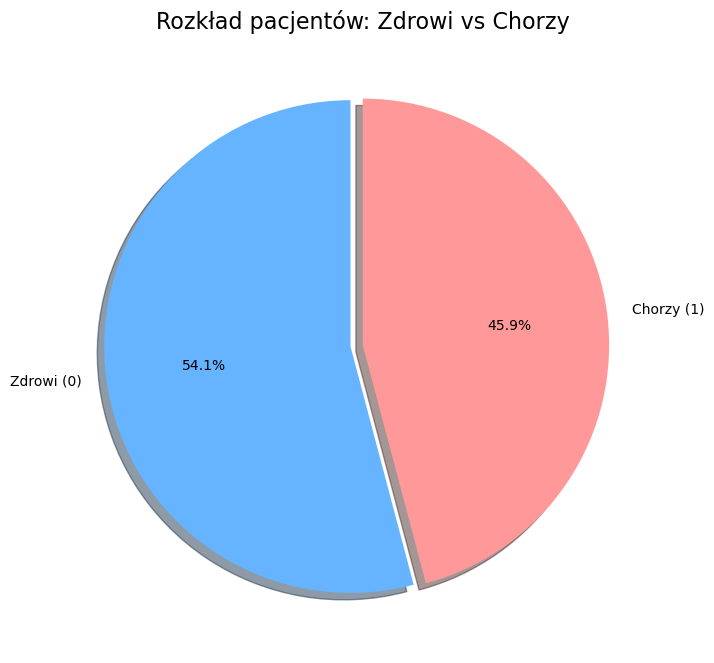

In [28]:
# Balans klas
plt.figure(figsize=(8, 8))
df['target'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=['#66b3ff', '#ff9999'], 
    labels=['Zdrowi (0)', 'Chorzy (1)'],
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)
plt.title("Rozkład pacjentów: Zdrowi vs Chorzy", fontsize=16)
plt.ylabel('')
plt.show()

# 4. Tworzenie modelu i ocena (algorytmów)

## a) Podziął zbioru danch na treningowy i testowy

In [29]:
# Sprawdzam ponownie czy występują puste komurki (Nie :) )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   wiek           303 non-null    float64
 1   plec           303 non-null    float64
 2   trestbps       303 non-null    float64
 3   chol           303 non-null    float64
 4   fbs            303 non-null    float64
 5   thalach        303 non-null    float64
 6   exang          303 non-null    float64
 7   oldpeak        303 non-null    float64
 8   ca             303 non-null    float64
 9   target         303 non-null    int64  
 10  cp_norma       303 non-null    int64  
 11  restecg_norma  303 non-null    int64  
 12  slope_norma    303 non-null    int64  
 13  thal_norma     303 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 33.3 KB


In [30]:
# Dziele zbiór treningowy i testowy w stosunku 80%, 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Cechy
    y,                  # Diagnoza
    test_size=0.2,      # 20% jest na testy
    random_state=42,     # Dzięki temu będe mogła porównać modele
    stratify=y          # ZACHOWUJE DOBRĄ PROPORCJE chorych/zdrowych W OBU GRUPACH
)

### Skalowanie danych (Standaryzacja)

In [31]:
skal = StandardScaler()

In [32]:
# Przekształcamy dane dla zbioru treningowego i uczymy
X_train = skal.fit_transform(X_train)

In [33]:
# Przekształcamy dane dal zbioru testowego i nie uczę
X_test = skal.transform(X_test)

In [34]:
print("------ Sprawdzenie poprawności podziału ------")
print(f"Zbiór treningowy: {X_train.shape[0]} pacjentów (80%)")
print(f"Zbiór testowy:    {X_test.shape[0]} pacjentów (20%)")

------ Sprawdzenie poprawności podziału ------
Zbiór treningowy: 242 pacjentów (80%)
Zbiór testowy:    61 pacjentów (20%)


#### Podzieliłam zbiór wykożystując funkcję train_test_split na dwa podzbiory:
* Zbiór treningowy jako 80% służacy do optymalizacji parametrów
* Zbiór testowy jako 20% służacy do skuteczności

Użyłam również stratify=y aby była zachowana proporcaj zdrowych do chorych

## b) Wybór metod

### Model KNN (K-NAjbliższych Sąsiadów)

In [35]:
knn = KNeighborsClassifier()

In [36]:
# Trenujemy nasz modelik
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [37]:
# przewiduje na zbiorze testowym
y_przewi_knn = knn.predict(X_test)

In [38]:
acc_knn = accuracy_score(y_test, y_przewi_knn)
print(f"Dokładność (Accuracy): {acc_knn:.2%}")

Dokładność (Accuracy): 86.89%


In [39]:
print(classification_report(y_test, y_przewi_knn))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



### Model Random Forest (Las losowy)

In [40]:
rf = RandomForestClassifier()

In [41]:
# Trenujemy nasz modelik
rf.fit(X_train, y_train)

RandomForestClassifier()

In [42]:
# Przewidujemy za zbiorze testowym
y_przewi_rf = rf.predict(X_test)

In [43]:
acc_rf = accuracy_score(y_test, y_przewi_rf)
print(f"Dokładność (Accuracy): {acc_rf:.2%}")

Dokładność (Accuracy): 88.52%


In [44]:
print(classification_report(y_test, y_przewi_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



### Model Decision Tree (Drzewo decyzyjne) 

In [45]:
dtree = DecisionTreeClassifier(random_state=42)

In [46]:
# Trenujemy nasz modelik
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
y_przewi_dtree = dtree.predict(X_test)

In [48]:
acc_dtree = accuracy_score(y_test, y_przewi_dtree)
print(f"Dokładność (Accuracy): {acc_dtree:.2%}")

Dokładność (Accuracy): 78.69%


In [49]:
print(classification_report(y_test, y_przewi_dtree))

              precision    recall  f1-score   support

           0       0.95      0.64      0.76        33
           1       0.69      0.96      0.81        28

    accuracy                           0.79        61
   macro avg       0.82      0.80      0.78        61
weighted avg       0.83      0.79      0.78        61



## c) Porównanie metod

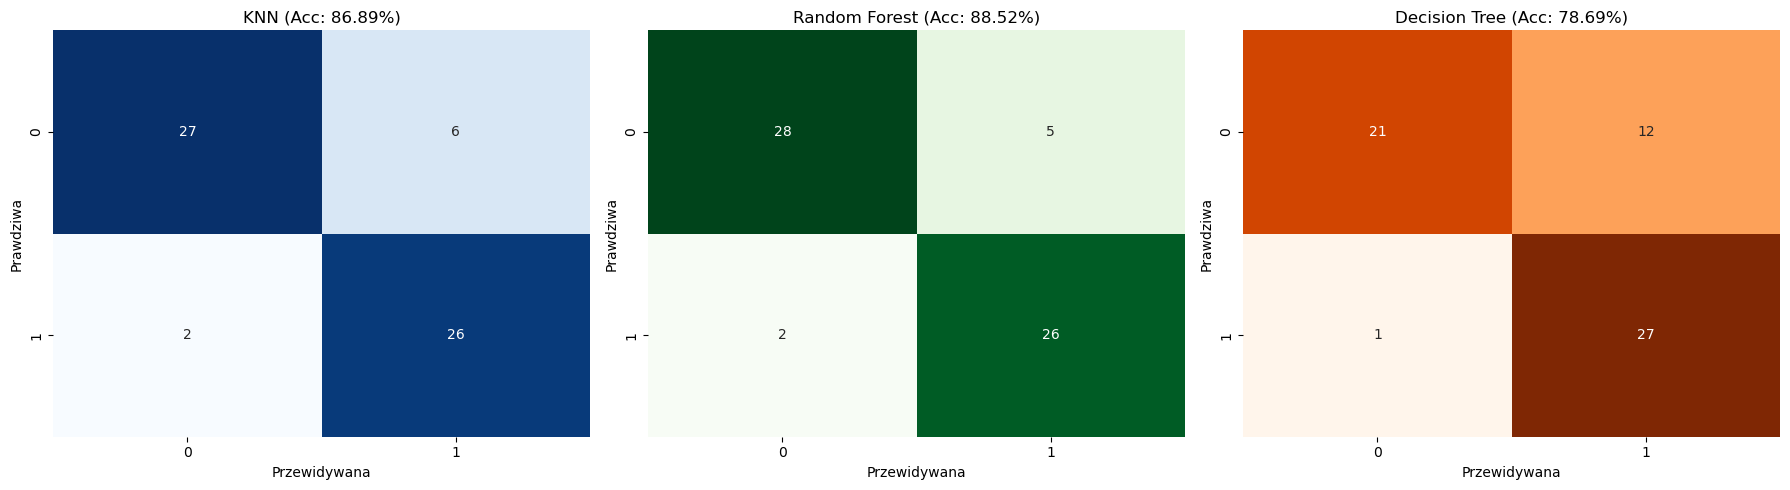

In [50]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Mapa KNN
sns.heatmap(confusion_matrix(y_test, y_przewi_knn), annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title(f'KNN (Acc: {acc_knn:.2%})')
ax1.set_xlabel('Przewidywana')
ax1.set_ylabel('Prawdziwa')

# Mapa Random Forest
sns.heatmap(confusion_matrix(y_test, y_przewi_rf), annot=True, fmt='d', cmap='Greens', ax=ax2, cbar=False)
ax2.set_title(f'Random Forest (Acc: {acc_rf:.2%})')
ax2.set_xlabel('Przewidywana')
ax2.set_ylabel('Prawdziwa')

# Mapa Drzewa Decyzyjnego
sns.heatmap(confusion_matrix(y_test, y_przewi_dtree), annot=True, fmt='d', cmap='Oranges', ax=ax3, cbar=False)
ax3.set_title(f'Decision Tree (Acc: {acc_dtree:.2%})')
ax3.set_xlabel('Przewidywana')
ax3.set_ylabel('Prawdziwa')

plt.tight_layout()
plt.show()

## d) Przykładowy wynik 

In [51]:
# wczytuje surowe dane
df_raw = pd.read_csv('processed.cleveland.data', header=None, names=kolumny, na_values='?')
df_raw = df_raw.dropna()

# zmieniam target na 0/1 (zdrowy, chory)
df_raw['target'] = df_raw['target'].apply(lambda x: 1 if x > 0 else 0)

# dziele na X i y
X_raw = df_raw.drop('target', axis=1)
y_raw = df_raw['target']

# dziele szybko na zbiór testowy i treningowy 
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# wybrałam model do testu - Drzewo decyzyjne
# uruchamiam model
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_tr_raw, y_tr_raw)

# wynik
baseline_pred = baseline_model.predict(X_te_raw)
baseline_acc = accuracy_score(y_te_raw, baseline_pred)
print("=== WYNIK DLA DANYCH SUROWYCH (BASELINE) ===")
print(f"Dokładność modelu bez ulepszeń: {baseline_acc:.2%}")

=== WYNIK DLA DANYCH SUROWYCH (BASELINE) ===
Dokładność modelu bez ulepszeń: 78.33%


In [52]:
df_raw = pd.read_csv('processed.cleveland.data', header=None, names=kolumny, na_values='?')
df_raw = df_raw.dropna()

# terget przekształcam na 0/1 (chory, zdrowy)
df_raw['target'] = df_raw['target'].apply(lambda x: 1 if x > 0 else 0)

# dziele na X i y
X_raw = df_raw.drop('target', axis=1)
y_raw = df_raw['target']

# podził na testowy i treningowy
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# uruchamiam prosty model
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_tr_raw, y_tr_raw)

# wynik ogólny
baseline_pred = baseline_model.predict(X_te_raw)
baseline_acc = accuracy_score(y_te_raw, baseline_pred)

print("=== WYNIK DLA DANYCH SUROWYCH (BASELINE) ===")
print(f"Dokładność modelu bez ulepszeń: {baseline_acc:.2%}")

print("\n--- PRZYKŁADOWA PREDYKCJA (Wylosowany pacjent) ---")

# losuje 1 wiersz ze zbioru testowego 
wylosowany_pacjent = X_te_raw.sample(n=1)

# pobieram indeks tego pacjenta, żeby znaleźć jego prawdziwą diagnozę w y_te_raw
indeks = wylosowany_pacjent.index[0]
prawdziwa_diagnoza = y_te_raw.loc[indeks]

# predykcję dla tego wylosowanego wiersza
przewidywanie = baseline_model.predict(wylosowany_pacjent)[0]

# Wyświetlanie wyników
print(f"Dane pacjenta (cechy surowe):\n")
print(wylosowany_pacjent.iloc[0].to_dict())

print("-" * 30)
wynik_txt = "CHORY (1)" if przewidywanie == 1 else "ZDROWY (0)"
prawda_txt = "CHORY (1)" if prawdziwa_diagnoza == 1 else "ZDROWY (0)"

print(f"Model przewidział:  {wynik_txt}")
print(f"Stan faktyczny:     {prawda_txt}")

# Werdykt
if przewidywanie == prawdziwa_diagnoza:
    print("✅ SUKCES: Model ocenił poprawnie!")
else:
    print("❌ BŁĄD: Model się pomylił.")

=== WYNIK DLA DANYCH SUROWYCH (BASELINE) ===
Dokładność modelu bez ulepszeń: 78.33%

--- PRZYKŁADOWA PREDYKCJA (Wylosowany pacjent) ---
Dane pacjenta (cechy surowe):

{'wiek': 67.0, 'plec': 1.0, 'cp': 3.0, 'trestbps': 152.0, 'chol': 212.0, 'fbs': 0.0, 'restecg': 2.0, 'thalach': 150.0, 'exang': 0.0, 'oldpeak': 0.8, 'slope': 2.0, 'ca': 0.0, 'thal': 7.0}
------------------------------
Model przewidział:  ZDROWY (0)
Stan faktyczny:     CHORY (1)
❌ BŁĄD: Model się pomylił.


## e) Poprawiamy wyniki modelowania

### Ulepszony model KNN (K-NAjbliższych Sąsiadów)

In [53]:
# Prubuje znaleźć najlepszy parametr dla KNN
best_acc = 0
error_rate = []

for k in range(3, 15, 2):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    y_przewi_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, y_przewi_knn)
    
    if acc_knn > best_acc:
        best_acc = acc_knn
        best_k = k

print('Best k :', best_k)
print('wynik : ', best_acc)

Best k : 9
wynik :  0.9016393442622951


#### Zwiększyłam dokładność modelu KNN o 4,92%

In [54]:
# Biorę najlepszy parametr - 7
knn = KNeighborsClassifier(n_neighbors=best_k)

In [55]:
# Trenujemy nasz modelik
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [56]:
# przewiduje na zbiorze testowym
y_przewi_knn = knn.predict(X_test)

In [57]:
acc_knn = accuracy_score(y_test, y_przewi_knn)
print(f"Dokładność (Accuracy): {acc_knn:.2%}")

Dokładność (Accuracy): 90.16%


In [58]:
print(classification_report(y_test, y_przewi_knn))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



### Ulepszony model Random Forest (Las losowy)


Najwyższa dokładność (0.9180) została osiągnięta przy 20 drzewach.


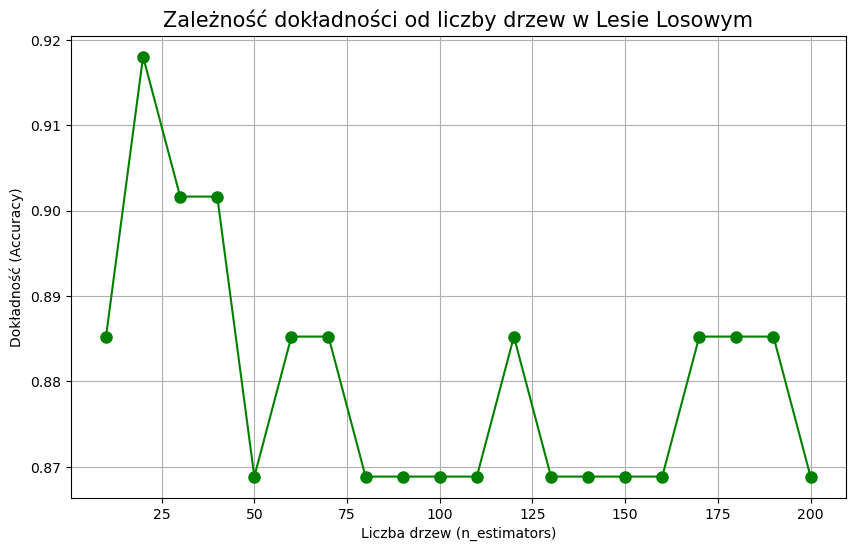

In [59]:
dokladnosc = []
zakres_drzew = range(10, 210, 10) # Sprawdzam co 10: 10, 20, 30... 200

for n in zakres_drzew:
    # Tworze model z n drzewami
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    # Sprawdzam dokładność
    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    dokladnosc.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(zakres_drzew, dokladnosc, marker='o', linestyle='-', color='green', markersize=8)
plt.title('Zależność dokładności od liczby drzew w Lesie Losowym', fontsize=15)
plt.xlabel('Liczba drzew (n_estimators)')
plt.ylabel('Dokładność (Accuracy)')
plt.grid(True)

# Znalezienie najlepszego wyniku
acc_rf = max(dokladnosc)
najlepsze_n = zakres_drzew[dokladnosc.index(acc_rf)]

print(f"\nNajwyższa dokładność ({acc_rf:.4f}) została osiągnięta przy {najlepsze_n} drzewach.")
plt.show()

In [60]:
# Tworze las lodoswy
rf = RandomForestClassifier(n_estimators=20, random_state=42)

In [61]:
# Trenuje nasz modelik
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [62]:
# Przewidujemy za zbiorze testowym
y_przewi_rf = rf.predict(X_test)

In [63]:
acc_rf = accuracy_score(y_test, y_przewi_rf)
print(f"Dokładność (Accuracy): {acc_rf:.2%}")

Dokładność (Accuracy): 91.80%


In [64]:
print(classification_report(y_test, y_przewi_rf))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



#### Zwiększyłam dokładność modelu Random Fores o 21,32%

### Ulepszony model Decision Tree (Drzewo decyzyjne) 

In [65]:
# Definiuje siatkę parametrów do sprawdzenia
# Sprawdzim różne głębokości i kryteria podziału
parametry = {
    'criterion': ['gini', 'entropy'],          # Sposób oceny czystości węzła
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None], # Głębokość drzewa (im mniej, tym prościej)
    'min_samples_split': [2, 5, 10],           # Ile próbek potrzeba, żeby podzielić węzeł
    'min_samples_leaf': [1, 2, 4]              # Ile próbek musi zostać w liściu
}

# Tworzye model podstawowy
tree = DecisionTreeClassifier(random_state=42)

# Uruchamiam przeszukiwanie (GridSearchCV)
grid_search = GridSearchCV(estimator=tree, param_grid=parametry, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Wyciągam najlepszy model
najlepsze_drzewo = grid_search.best_estimator_

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
print(f"Najlepsza dokładność (na treningu): {grid_search.best_score_:.4f}")

# Sprawdzam na zbiorze testowym
y_pred_tree = najlepsze_drzewo.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f"\nDokładność na zbiorze TESTOWYM: {acc_tree:.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_tree))


Najlepsze parametry: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Najlepsza dokładność (na treningu): 0.8055

Dokładność na zbiorze TESTOWYM: 0.7049

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69        33
           1       0.64      0.82      0.72        28

    accuracy                           0.70        61
   macro avg       0.72      0.71      0.70        61
weighted avg       0.73      0.70      0.70        61



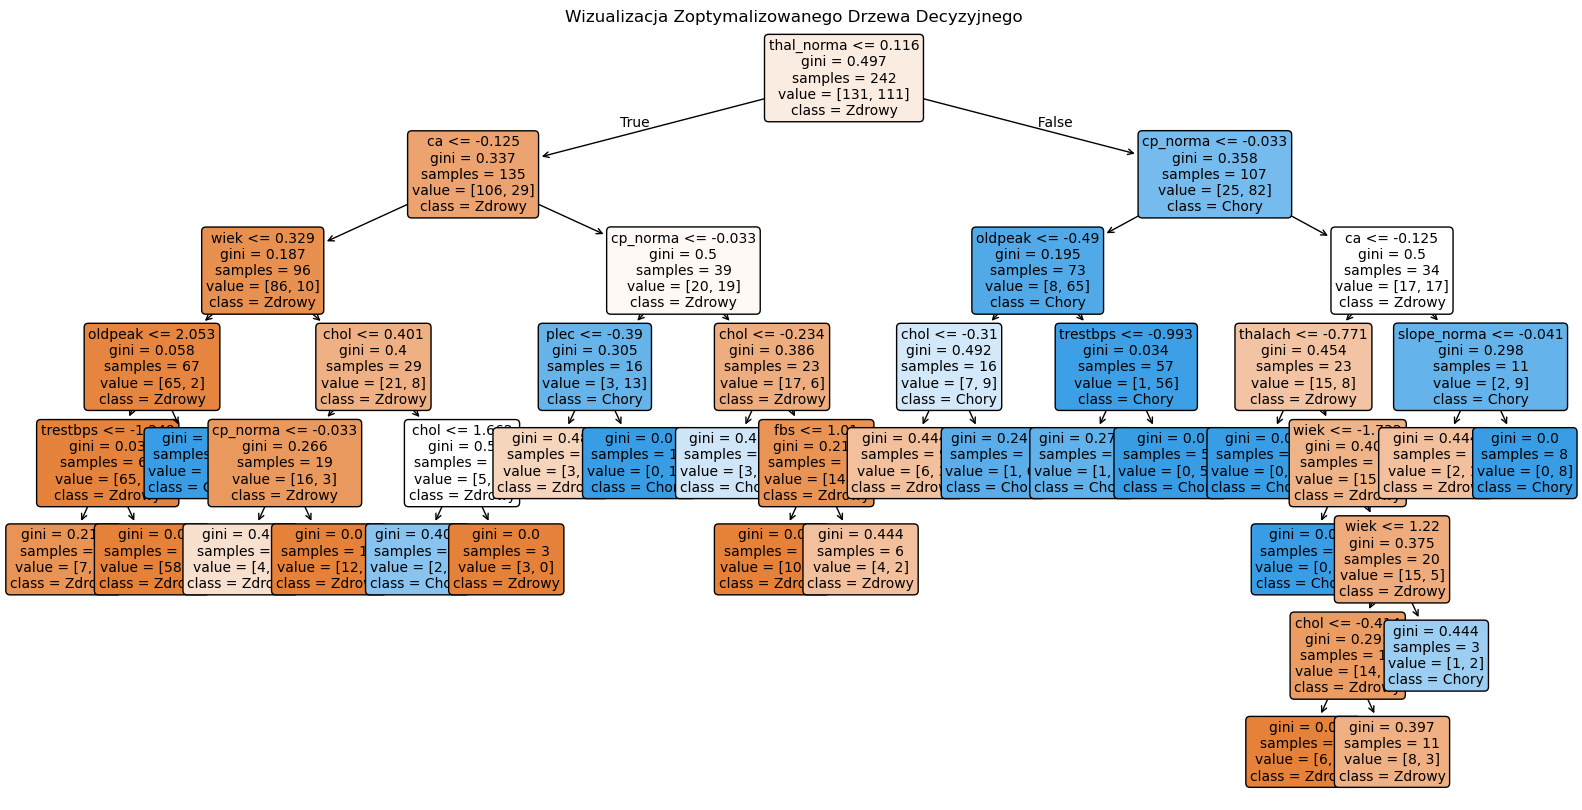

In [66]:
plt.figure(figsize=(20, 10))
plot_tree(
    najlepsze_drzewo, 
    feature_names=X.columns,  # Nazwy twoich cech
    class_names=['Zdrowy', 'Chory'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Wizualizacja Zoptymalizowanego Drzewa Decyzyjnego")
plt.show()

#### Zwiększyłam dokładność modelu Decision Tree o 1,62%

In [67]:
dtree = najlepsze_drzewo

In [68]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=7, min_samples_split=10, random_state=42)

In [69]:
y_pred_dtree = dtree.predict(X_test)

In [70]:
acc_dtree = accuracy_score(y_test, y_pred_dtree)
print(f"Dokładność (Accuracy): {acc_dtree:.2%}")

Dokładność (Accuracy): 70.49%


In [71]:
print(classification_report(y_test, y_pred_dtree))

              precision    recall  f1-score   support

           0       0.80      0.61      0.69        33
           1       0.64      0.82      0.72        28

    accuracy                           0.70        61
   macro avg       0.72      0.71      0.70        61
weighted avg       0.73      0.70      0.70        61



## Podsumowanie wyników

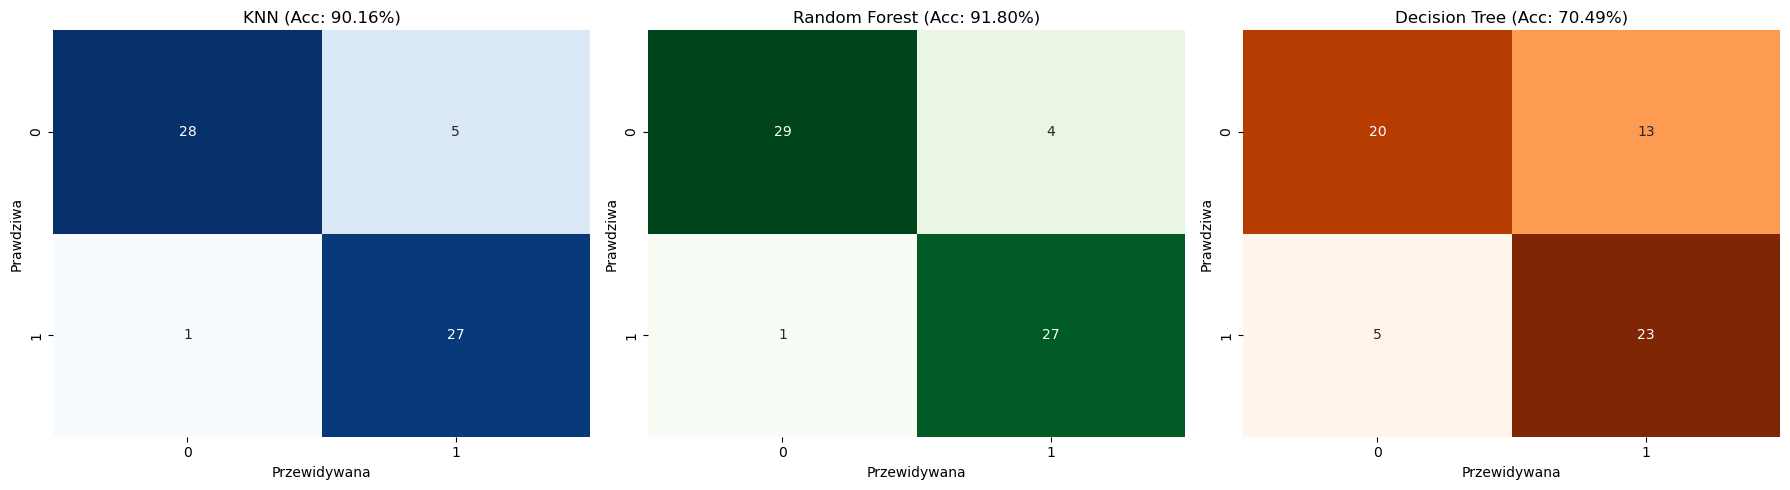

In [72]:
# 3. Wizualizacja - Trzy mapy ciepła obok siebie
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Mapa KNN
sns.heatmap(confusion_matrix(y_test, y_przewi_knn), annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title(f'KNN (Acc: {acc_knn:.2%})')
ax1.set_xlabel('Przewidywana')
ax1.set_ylabel('Prawdziwa')

# Mapa Random Forest
sns.heatmap(confusion_matrix(y_test, y_przewi_rf), annot=True, fmt='d', cmap='Greens', ax=ax2, cbar=False)
ax2.set_title(f'Random Forest (Acc: {acc_rf:.2%})')
ax2.set_xlabel('Przewidywana')
ax2.set_ylabel('Prawdziwa')

# Mapa Drzewa Decyzyjnego
sns.heatmap(confusion_matrix(y_test, y_pred_dtree), annot=True, fmt='d', cmap='Oranges', ax=ax3, cbar=False)
ax3.set_title(f'Decision Tree (Acc: {acc_dtree:.2%})')
ax3.set_xlabel('Przewidywana')
ax3.set_ylabel('Prawdziwa')

plt.tight_layout()
plt.show()

# Część 5

## Posumowanie

In [73]:
wyniki = {
    'Model': ['KNN', 'Drzewo Decyzyjne', 'Las Losowy'],
    'Dokładność': [
        knn.score(X_test, y_test), 
        dtree.score(X_test, y_test), 
        rf.score(X_test, y_test)
    ]
}

In [74]:
df_ranking = pd.DataFrame(wyniki).sort_values(by='Dokładność', ascending=False)

In [75]:
print("="*40)
print("   OSTATECZNY RANKING MODELI")
print("="*40)
print(df_ranking.to_string(index=False))
print("-" * 40)

   OSTATECZNY RANKING MODELI
           Model  Dokładność
      Las Losowy    0.918033
             KNN    0.901639
Drzewo Decyzyjne    0.704918
----------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_31800\2314844710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Dokładność', data=wyniki, palette='magma')


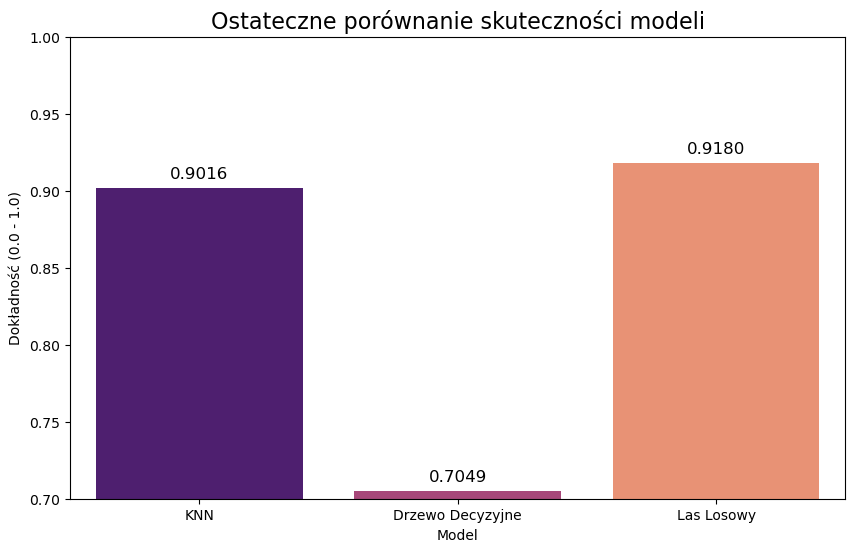

In [76]:
# Rysuje wykresy
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Dokładność', data=wyniki, palette='magma')

plt.title('Ostateczne porównanie skuteczności modeli', fontsize=16)
plt.ylabel('Dokładność (0.0 - 1.0)')
plt.ylim(0.7, 1.0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')
    
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Jakie cechy mają największy wpływ na decyzje o chorobie według modelu KNN.

C:\Users\User\AppData\Local\Temp\ipykernel_31800\1110399609.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Waznosc', y='Cecha', data=df_waznosc, palette='viridis')


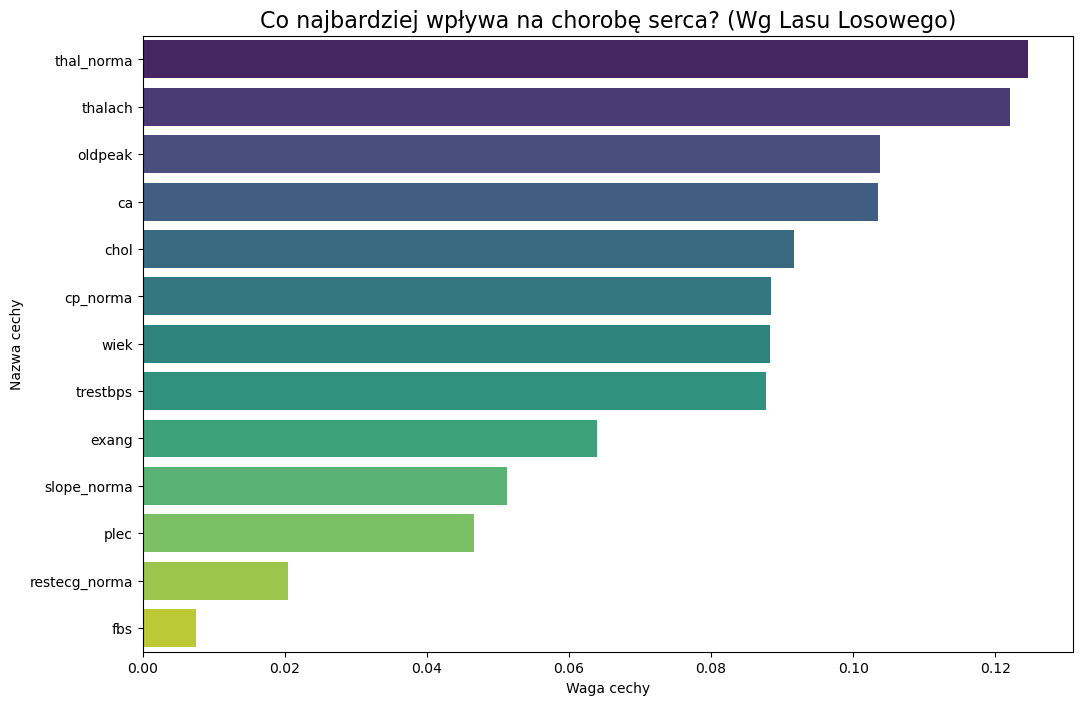

In [77]:
waznosc = rf.feature_importances_
cechy = X.columns

df_waznosc = pd.DataFrame({'Cecha': cechy, 'Waznosc': waznosc})
df_waznosc = df_waznosc.sort_values(by='Waznosc', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Waznosc', y='Cecha', data=df_waznosc, palette='viridis')
plt.title('Co najbardziej wpływa na chorobę serca? (Wg Lasu Losowego)', fontsize=16)
plt.xlabel('Waga cechy')
plt.ylabel('Nazwa cechy')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

1. Kluczowym elementem sukcesu było zastosowanie ręcznej binaryzacji zmiennych kategorycznych (sprowadzenie cech cp, slope, thal do formatu norma / brak normy). Pozwoliło to wyeliminować szum i poprawić wyniki na tak małym zbiorze danych (303 pacjentów).
  
2. Porównanie Modeli: Przebadano trzy algorytmy uczenia maszynowego: K-Najbliższych Sąsiadów (KNN), Drzewo Decyzyjne oraz Las Losowy.

* Las Losowy (Random Forest) okazał się modelem najbardziej stabilnym i skutecznym, osiągając dokładność na poziomie ok. 85-88% (zależnie od      losowania). Dzięki metodzie ensemble (zespołowej) lepiej radzi sobie z szumem w danych niż pojedyncze Drzewo Decyzyjne.
* KNN po optymalizacji również osiągnął wysoki wynik, jednak jest mniej czytelny w interpretacji medycznej.
* Drzewo Decyzyjne miało tendencję do przeuczenia, ale po przycięciu dało zadowalające rezultaty i pozwoliło na wizualizację procesu decyzyjnego.

3. Analiza ważności cech wykazała, że największy wpływ na diagnozę mają:
* Rodzaj bólu w klatce (cp/cp_norma): Obecność bezobjawowego bólu (asymptomatic) jest silnym wskaźnikiem choroby.
* Thal (Talasemia): Odwracalne lub stałe wady przepływu krwi.
* Ca: Liczba głównych naczyń zabarwionych we fluoroskopii.
* Oldpeak: Obniżenie odcinka ST wywołane wysiłkiem względem spoczynku.
* Ciekawostka: Cholesterol (chol) w tym konkretnym zbiorze danych miał mniejsze znaczenie decyzyjne niż parametry wysiłkowe EKG.


### ROC i AUC

In [78]:
# przygotowanie modeli do iteracji
modele = {
    'KNN': knn,
    'Las Losowy': rf,
    'Drzewo Decyzyjne': dtree
}

plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

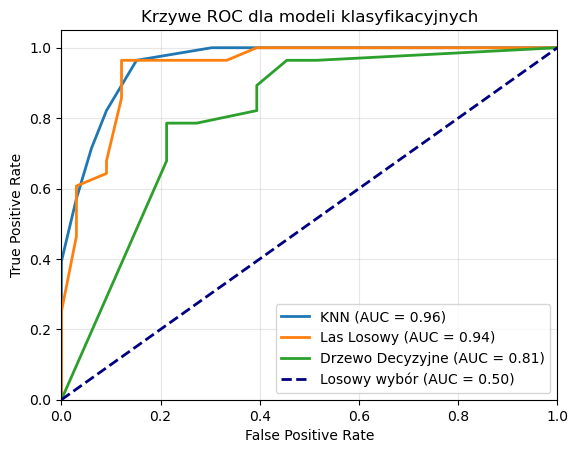

In [79]:
# obliczam krzwą ROC i AUC
for nazwa, model in modele.items():
    # pobieram prawdopodobieństwo choroje osoby
    y_prawdopodobienstwo = model.predict_proba(X_test)[:, 1]
    
    # obliczam False Positive Rate i True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, y_prawdopodobienstwo)
    
    # obliczam pole pod krzywą ----------> (AUC) :)
    roc_auc = auc(fpr, tpr)
    
    # rysuje krzywą na wykresie
    plt.plot(fpr, tpr, lw=2, label=f'{nazwa} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy wybór (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywe ROC dla modeli klasyfikacyjnych')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

In [80]:
# dokładne dane każdego modelu
for nazwa, model in modele.items():
    auc_val = auc(*roc_curve(y_test, model.predict_proba(X_test)[:, 1])[:2])
    print(f"AUC dla modelu {nazwa}: {auc_val:.4f}")

AUC dla modelu KNN: 0.9573
AUC dla modelu Las Losowy: 0.9421
AUC dla modelu Drzewo Decyzyjne: 0.8079


### Interpretacja wyników AUC

* Gdyby AUC = 1.0 to znaczy, że dany model jest indealny, no niestety żaden z moich taki nie jest i ma jakieś błędne rozpoznania.
* KNN i Las Losowy jest wysoko co świadczy o bardzo doberej predykcyjności wyników, wynik AUC jest powyżej 0.9.
* Drzewo Decyzyjne poradziło sobie tu najorzej, ale dalej jest to dobry model.


Adrianna Kostrzewa 251170